### Reimplementation on paper dataset

We Reimplement our own CycleNet-Linear on one real dataset used in the paper, then compare it to a Linear baseline.



We start by using the **ETTh1** dataset.

About the dataset: Electricity Transformer Temperature (ETT) dataset collection. It is a widely recognized benchmark dataset heavily used in data science and machine learning for multivariate time-series forecasting. It tracks the electrical load and thermal state of an electricity power transformer over a two-year period.


to replicate the following reimplementation:

1) you can download the dataset at this link provided by the authors: https://drive.google.com/file/d/1bNbw1y8VYp-8pkRTqbjoW-TA-G8T0EQf/view


2) inside this repo create a folder named **paper_code** and clone the author's repository: https://github.com/ACAT-SCUT/CycleNet 



On terminal:

```bash
mkdir paper_code
cd paper_code
git clone [https://github.com/ACAT-SCUT/CycleNet.git](https://github.com/ACAT-SCUT/CycleNet.git)
```

3) then create the dataset folder inside the CycleNet repository and insert there the downloaded data. e.g. ../dataset/ETTh1.csv



In [130]:
ROOT_PATH = "../paper_code/CycleNet/dataset"
DATA_PATH = "ETTh1.csv"

In [131]:
from pathlib import Path
import sys
import torch
from torch.utils.data import DataLoader

# Path to official CycleNet repo
REPO_DIR = Path("../paper_code/CycleNet").resolve()
sys.path.append(str(REPO_DIR))

ROOT_PATH = "../paper_code/CycleNet/dataset"
DATA_PATH = "ETTh1.csv"

print("Repo dir:", REPO_DIR)
print("Dataset exists:", Path(ROOT_PATH, DATA_PATH).exists())

Repo dir: /Users/ferdansk/Desktop/AdvML/paper_code/CycleNet
Dataset exists: True


In [132]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Useful for reproducibility, though full determinism is not always guaranteed on every backend
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 0. Import the data 

We import the dataset using the official CycleNet dataloader, and then slightly change its shape to match our reimplementation guidelines

In [133]:
from data_provider.data_loader import Dataset_ETT_hour

seq_len = 96
label_len = 48
pred_len = 336
cycle_len = 24
batch_size = 32

train_dataset = Dataset_ETT_hour(
    root_path=ROOT_PATH,
    flag="train",
    size=[seq_len, label_len, pred_len],
    features="M",
    data_path=DATA_PATH,
    target="OT",
    scale=True,
    timeenc=1,
    freq="h",
    cycle=cycle_len,
)

val_dataset = Dataset_ETT_hour(
    root_path=ROOT_PATH,
    flag="val",
    size=[seq_len, label_len, pred_len],
    features="M",
    data_path=DATA_PATH,
    target="OT",
    scale=True,
    timeenc=1,
    freq="h",
    cycle=cycle_len,
)

test_dataset = Dataset_ETT_hour(
    root_path=ROOT_PATH,
    flag="test",
    size=[seq_len, label_len, pred_len],
    features="M",
    data_path=DATA_PATH,
    target="OT",
    scale=True,
    timeenc=1,
    freq="h",
    cycle=cycle_len,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 8209
Val samples: 2545
Test samples: 2545


In [134]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)


def prepare_batch(batch, pred_len, device):
    """
    Converts the official CycleNet loader output into the format used
    by our simple Linear / CycleNet reimplementation.

    Official loader returns:
        batch_x, batch_y, batch_x_mark, batch_y_mark, cycle_idx

    We use:
        x = batch_x
        y = last pred_len steps of batch_y
        cycle_idx = cycle_idx
    """
    batch_x, batch_y, batch_x_mark, batch_y_mark, cycle_idx = batch

    x = batch_x.float().to(device)
    y = batch_y[:, -pred_len:, :].float().to(device)
    cycle_idx = cycle_idx.long().to(device)

    return x, y, cycle_idx

Using device: mps


In [135]:
# batch inspection 

batch = next(iter(train_loader))

x_real, y_real, cycle_idx_real = prepare_batch(
    batch,
    pred_len=pred_len,
    device=device
)

print("x_real shape:", x_real.shape)
print("y_real shape:", y_real.shape)
print("cycle_idx_real shape:", cycle_idx_real.shape)
print("cycle_idx_real example:", cycle_idx_real[:10])

x_real shape: torch.Size([32, 96, 7])
y_real shape: torch.Size([32, 336, 7])
cycle_idx_real shape: torch.Size([32])
cycle_idx_real example: tensor([ 7, 14, 19, 18,  1,  1, 16, 20, 17,  8], device='mps:0')


Note: The current indexing is: 

past cycle indices   = cycle_idx - seq_len, ..., cycle_idx - 1 <cd>

future cycle indices = cycle_idx, ..., cycle_idx + pred_len - 1



### 1. Defining the models 

here, we align closely to the model definition of the paper 



To replicate the setup,we  use the following specific configurations:

* **Dataset:** Use the authors’ dataset.
* **Chronological Split (ETTh1):** 
  * **Train:** 12 months
  * **Validation:** 4 months
  * **Test:** 4 months
* **Preprocessing:** Fit `StandardScaler` **only** on the training portion.
* **Forecasting Mode:** Multivariate (`features="M"`).
* **Sequence Parameters:**
  * `seq_len = 96`
  * `label_len = 48`
  * `pred_len = 96`
* **Cycle Settings:**
  * `cycle_len = 24`
  * Utilize their returned `cycle_index`.
* **CycleNet Mechanism:** Apply the official mechanism exactly as follows:
  1. RecurrentCycle
  2. RevIN-style normalization
  3. Subtract cycle
  4. Linear backbone
  5. Add future cycle back

In [136]:
import torch
import torch.nn as nn


class RecurrentCycle(nn.Module):
    def __init__(self, cycle_len, channel_size):
        super().__init__()
        self.cycle_len = cycle_len
        self.channel_size = channel_size

        # Learnable cycle table: [cycle_len, num_channels]
        self.data = nn.Parameter(
            torch.zeros(cycle_len, channel_size),
            requires_grad=True
        )

    def forward(self, index, length):
        """
        index: [B]
        returns: [B, length, C]
        """
        gather_index = (
            index.view(-1, 1)
            + torch.arange(length, device=index.device).view(1, -1)
        ) % self.cycle_len

        return self.data[gather_index]


class LinearBaseline(nn.Module):
    def __init__(self, seq_len, pred_len, enc_in, use_revin=True):
        super().__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.enc_in = enc_in
        self.use_revin = use_revin

        self.linear = nn.Linear(seq_len, pred_len)

    def forward(self, x):
        """
        x: [B, L, C]
        returns: [B, H, C]
        """

        if self.use_revin:
            seq_mean = torch.mean(x, dim=1, keepdim=True)
            seq_var = torch.var(x, dim=1, keepdim=True) + 1e-5
            x = (x - seq_mean) / torch.sqrt(seq_var)

        # Channel-independent linear forecasting
        y = self.linear(x.permute(0, 2, 1)).permute(0, 2, 1)

        if self.use_revin:
            y = y * torch.sqrt(seq_var) + seq_mean

        return y


class CycleNetLinear(nn.Module):
    def __init__(self, seq_len, pred_len, enc_in, cycle_len, use_revin=True):
        super().__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.enc_in = enc_in
        self.cycle_len = cycle_len
        self.use_revin = use_revin

        self.cycleQueue = RecurrentCycle(
            cycle_len=cycle_len,
            channel_size=enc_in
        )

        self.model = nn.Linear(seq_len, pred_len)

    def forward(self, x, cycle_index):
        """
        x: [B, L, C]
        cycle_index: [B]
        returns: [B, H, C]
        """

        if self.use_revin:
            seq_mean = torch.mean(x, dim=1, keepdim=True)
            seq_var = torch.var(x, dim=1, keepdim=True) + 1e-5
            x = (x - seq_mean) / torch.sqrt(seq_var)

        # Remove learned cycle from input
        x = x - self.cycleQueue(cycle_index, self.seq_len)

        # Forecast residual using Linear backbone
        y = self.model(x.permute(0, 2, 1)).permute(0, 2, 1)

        # Add future learned cycle back
        y = y + self.cycleQueue(
            (cycle_index + self.seq_len) % self.cycle_len,
            self.pred_len
        )

        if self.use_revin:
            y = y * torch.sqrt(seq_var) + seq_mean

        return y

In [137]:
batch = next(iter(train_loader))
x_real, y_real, cycle_idx_real = prepare_batch(batch, pred_len, device)

enc_in = x_real.shape[-1]

linear_model = LinearBaseline(
    seq_len=seq_len,
    pred_len=pred_len,
    enc_in=enc_in,
    use_revin=True
).to(device)

cyclenet_model = CycleNetLinear(
    seq_len=seq_len,
    pred_len=pred_len,
    enc_in=enc_in,
    cycle_len=cycle_len,
    use_revin=True
).to(device)

with torch.no_grad():
    linear_out = linear_model(x_real)
    cyclenet_out = cyclenet_model(x_real, cycle_idx_real)

print("Linear output shape:", linear_out.shape)
print("CycleNet output shape:", cyclenet_out.shape)
print("Target shape:", y_real.shape)



Linear output shape: torch.Size([32, 336, 7])
CycleNet output shape: torch.Size([32, 336, 7])
Target shape: torch.Size([32, 336, 7])


### 2. Training and comparing the models 

In [138]:
# Training and evaluation functions

from tqdm import tqdm
import copy
import pandas as pd

def train_one_model(
    model,
    train_loader,
    val_loader,
    pred_len,
    device,
    uses_cycle=False,
    lr=1e-3,
    num_epochs=20,
):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_mse": [],
        "val_mse": [],
        "val_mae": [],
    }

    best_val_mse = float("inf")
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        train_squared_error = 0.0
        train_values = 0

        for batch in train_loader:
            x_batch, y_batch, cycle_idx = prepare_batch(batch, pred_len, device)

            optimizer.zero_grad()

            if uses_cycle:
                y_pred = model(x_batch, cycle_idx)
            else:
                y_pred = model(x_batch)

            loss = criterion(y_pred, y_batch)

            loss.backward()
            optimizer.step()

            train_squared_error += ((y_pred.detach() - y_batch) ** 2).sum().item()
            train_values += y_batch.numel()

        train_mse = train_squared_error / train_values
        val_mse, val_mae = evaluate_one_model(
            model,
            val_loader,
            pred_len,
            device,
            uses_cycle=uses_cycle,
        )

        history["train_mse"].append(train_mse)
        history["val_mse"].append(val_mse)
        history["val_mae"].append(val_mae)

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1:03d}/{num_epochs} | "
            f"Train MSE: {train_mse:.6f} | "
            f"Val MSE: {val_mse:.6f} | "
            f"Val MAE: {val_mae:.6f}"
        )

    model.load_state_dict(best_state)

    return model, history


def evaluate_one_model(
    model,
    data_loader,
    pred_len,
    device,
    uses_cycle=False,
):
    model.eval()

    total_squared_error = 0.0
    total_absolute_error = 0.0
    total_values = 0

    with torch.no_grad():
        for batch in data_loader:
            x_batch, y_batch, cycle_idx = prepare_batch(batch, pred_len, device)

            if uses_cycle:
                y_pred = model(x_batch, cycle_idx)
            else:
                y_pred = model(x_batch)

            total_squared_error += ((y_pred - y_batch) ** 2).sum().item()
            total_absolute_error += torch.abs(y_pred - y_batch).sum().item()
            total_values += y_batch.numel()

    mse = total_squared_error / total_values
    mae = total_absolute_error / total_values

    return mse, mae

In [139]:
# Training and evaluating the Linear baseline

enc_in = 7

linear_model = LinearBaseline(
    seq_len=seq_len,
    pred_len=pred_len,
    enc_in=enc_in,
    use_revin=True,
)

linear_model, linear_history = train_one_model(
    model=linear_model,
    train_loader=train_loader,
    val_loader=val_loader,
    pred_len=pred_len,
    device=device,
    uses_cycle=False,
    lr=1e-3,
    num_epochs=20,
)

linear_test_mse, linear_test_mae = evaluate_one_model(
    linear_model,
    test_loader,
    pred_len,
    device,
    uses_cycle=False,
)

print(f"Linear Test MSE: {linear_test_mse:.6f}")
print(f"Linear Test MAE: {linear_test_mae:.6f}")

Epoch 001/20 | Train MSE: 0.526945 | Val MSE: 1.303762 | Val MAE: 0.765321
Epoch 002/20 | Train MSE: 0.491367 | Val MSE: 1.296301 | Val MAE: 0.760742
Epoch 003/20 | Train MSE: 0.487157 | Val MSE: 1.293445 | Val MAE: 0.758995
Epoch 004/20 | Train MSE: 0.485023 | Val MSE: 1.290281 | Val MAE: 0.758533
Epoch 005/20 | Train MSE: 0.483927 | Val MSE: 1.292952 | Val MAE: 0.757963
Epoch 006/20 | Train MSE: 0.483482 | Val MSE: 1.291874 | Val MAE: 0.758096
Epoch 007/20 | Train MSE: 0.482903 | Val MSE: 1.290952 | Val MAE: 0.757973
Epoch 008/20 | Train MSE: 0.482973 | Val MSE: 1.290447 | Val MAE: 0.757537
Epoch 009/20 | Train MSE: 0.482739 | Val MSE: 1.287433 | Val MAE: 0.756583
Epoch 010/20 | Train MSE: 0.482867 | Val MSE: 1.288012 | Val MAE: 0.756322
Epoch 011/20 | Train MSE: 0.482534 | Val MSE: 1.290254 | Val MAE: 0.757088
Epoch 012/20 | Train MSE: 0.482817 | Val MSE: 1.285798 | Val MAE: 0.755718
Epoch 013/20 | Train MSE: 0.482368 | Val MSE: 1.285694 | Val MAE: 0.756239
Epoch 014/20 | Train MSE:

In [140]:
# Training and evaluating CycleNet with Linear backbone 


cyclenet_model = CycleNetLinear(
    seq_len=seq_len,
    pred_len=pred_len,
    enc_in=enc_in,
    cycle_len=cycle_len,
    use_revin=True,
)

cyclenet_model, cyclenet_history = train_one_model(
    model=cyclenet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    pred_len=pred_len,
    device=device,
    uses_cycle=True,
    lr=1e-3,
    num_epochs=20,
)

cyclenet_test_mse, cyclenet_test_mae = evaluate_one_model(
    cyclenet_model,
    test_loader,
    pred_len,
    device,
    uses_cycle=True,
)

print(f"CycleNet-Linear Test MSE: {cyclenet_test_mse:.6f}")
print(f"CycleNet-Linear Test MAE: {cyclenet_test_mae:.6f}")


Epoch 001/20 | Train MSE: 0.520774 | Val MSE: 1.309242 | Val MAE: 0.765174
Epoch 002/20 | Train MSE: 0.486221 | Val MSE: 1.304833 | Val MAE: 0.761940
Epoch 003/20 | Train MSE: 0.482175 | Val MSE: 1.300504 | Val MAE: 0.760258
Epoch 004/20 | Train MSE: 0.479644 | Val MSE: 1.302168 | Val MAE: 0.760818
Epoch 005/20 | Train MSE: 0.478497 | Val MSE: 1.300217 | Val MAE: 0.759159
Epoch 006/20 | Train MSE: 0.477299 | Val MSE: 1.295460 | Val MAE: 0.758127
Epoch 007/20 | Train MSE: 0.476307 | Val MSE: 1.300822 | Val MAE: 0.759471
Epoch 008/20 | Train MSE: 0.475404 | Val MSE: 1.301265 | Val MAE: 0.759714
Epoch 009/20 | Train MSE: 0.474539 | Val MSE: 1.293731 | Val MAE: 0.757455
Epoch 010/20 | Train MSE: 0.473377 | Val MSE: 1.288901 | Val MAE: 0.756506
Epoch 011/20 | Train MSE: 0.472443 | Val MSE: 1.286321 | Val MAE: 0.755351
Epoch 012/20 | Train MSE: 0.471214 | Val MSE: 1.282776 | Val MAE: 0.753842
Epoch 013/20 | Train MSE: 0.470687 | Val MSE: 1.282498 | Val MAE: 0.754033
Epoch 014/20 | Train MSE:

In [141]:
summary = pd.DataFrame({
    "Model": ["Linear", "CycleNet-Linear"],
    "Best Val MSE": [
        min(linear_history["val_mse"]),
        min(cyclenet_history["val_mse"])
    ],
    "Best Val MAE": [
        linear_history["val_mae"][linear_history["val_mse"].index(min(linear_history["val_mse"]))],
        cyclenet_history["val_mae"][cyclenet_history["val_mse"].index(min(cyclenet_history["val_mse"]))]
    ],
    "Test MSE": [linear_test_mse, cyclenet_test_mse],
    "Test MAE": [linear_test_mae, cyclenet_test_mae],
})

summary

,Model,Best Val MSE,Best Val MAE,Test MSE,Test MAE
0,Linear,1.285226,0.755472,0.482642,0.446608
1,CycleNet-Linear,1.280403,0.752435,0.461598,0.437861


### Testing different Horizons

On ETTh1 with `seq_len=96`, `pred_len=96`, and `cycle_len=24`, and training with `epochs=20`, and optimizer Adam, CycleNet-Linear improves over the direct Linear baseline. The improvement is moderate. 

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>Best Val MSE</th>
      <th>Best Val MAE</th>
      <th>Test MSE</th>
      <th>Test MAE</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Linear</td>
      <td>0.691378</td>
      <td>0.545497</td>
      <td>0.388711</td>
      <td>0.395550</td>
    </tr>
    <tr>
      <th>1</th>
      <td>CycleNet-Linear</td>
      <td>0.687822</td>
      <td>0.543563</td>
      <td>0.377440</td>
      <td>0.391613</td>
    </tr>
  </tbody>
</table>
</div>



with larger horizon `pred_len=192` the task becomes harder for both models, though CycleNet Linear relative gain augments 

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>Best Val MSE</th>
      <th>Best Val MAE</th>
      <th>Test MSE</th>
      <th>Test MAE</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Linear</td>
      <td>0.992853</td>
      <td>0.652277</td>
      <td>0.440288</td>
      <td>0.424859</td>
    </tr>
    <tr>
      <th>1</th>
      <td>CycleNet-Linear</td>
      <td>0.988747</td>
      <td>0.649934</td>
      <td>0.424568</td>
      <td>0.418812</td>
    </tr>
  </tbody>
</table>
</div>


Augmenting the horizon further improves CyclenNet performance, supporting paper claim: **The stable periodic patterns present in time series data serve as the foundation for conducting long-horizon forecasts.**






Table of results:

| Horizon | Linear MSE | CycleNet MSE | MSE Improvement |
| ------: | ---------: | -----------: | --------------: |
|      96 |   0.388711 |     0.377440 |          ~2.90% |
|     192 |   0.440288 |     0.424568 |          ~3.57% |
|     336 |   0.482197 |     0.462739 |          ~4.04% |



### Testing different Cycle Lenghts

Keeping `pred_len=336`, how does Cycle Lenght affect our models? |

Table of results:

| Cycle length | Meaning  | CycleNet Test MSE | CycleNet Test MAE | Interpretation       |
| -----------: | -------- | ----------------: | ----------------: | -------------------- |
|           12 | half-day |          0.474201 |          0.442331 | helps, but weak      |
|           24 | daily    |          0.462739 |          0.439170 | best                 |
|           48 | two-day  |          0.463609 |          0.439088 | almost as good as 24 |
|          168 | weekly   |          0.479414 |          0.447642 | little/no benefit    |


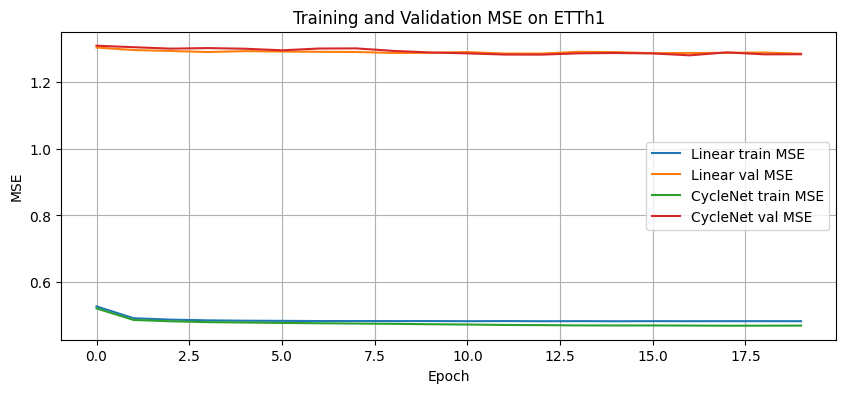

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(linear_history["train_mse"], label="Linear train MSE")
plt.plot(linear_history["val_mse"], label="Linear val MSE")

plt.plot(cyclenet_history["train_mse"], label="CycleNet train MSE")
plt.plot(cyclenet_history["val_mse"], label="CycleNet val MSE")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and Validation MSE on ETTh1")
plt.legend()
plt.grid(True)
plt.show()

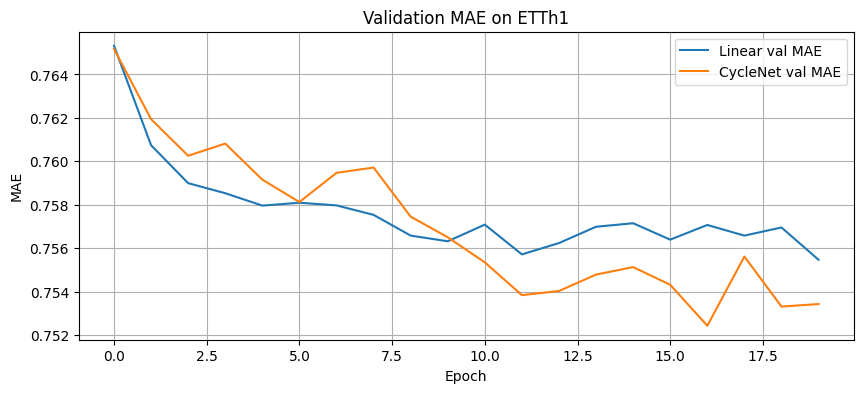

In [143]:
plt.figure(figsize=(10, 4))

plt.plot(linear_history["val_mae"], label="Linear val MAE")
plt.plot(cyclenet_history["val_mae"], label="CycleNet val MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Validation MAE on ETTh1")
plt.legend()
plt.grid(True)
plt.show()

### 3. Stronger Backbone: MLP vs CycleNet-MLP

In this section we check whether explicit cycle modeling still helps when the residual forecaster is stronger than a single Linear layer, nd wether it improves CycleNet further.

### 3.1 Defining the models 

In [145]:
class MLPBaseline(nn.Module):
    def __init__(self, seq_len, pred_len, enc_in, d_model=256, use_revin=True):
        super().__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.enc_in = enc_in
        self.d_model = d_model
        self.use_revin = use_revin

        self.model = nn.Sequential(
            nn.Linear(seq_len, d_model),
            nn.ReLU(),
            nn.Linear(d_model, pred_len)
        )

    def forward(self, x):
        """
        x: [B, L, C]
        returns: [B, H, C]
        """

        if self.use_revin:
            seq_mean = torch.mean(x, dim=1, keepdim=True)
            seq_var = torch.var(x, dim=1, keepdim=True) + 1e-5
            x = (x - seq_mean) / torch.sqrt(seq_var)

        # Channel-independent MLP forecasting
        y = self.model(x.permute(0, 2, 1)).permute(0, 2, 1)

        if self.use_revin:
            y = y * torch.sqrt(seq_var) + seq_mean

        return y


class CycleNetMLP(nn.Module):
    def __init__(self, seq_len, pred_len, enc_in, cycle_len, d_model=256, use_revin=True):
        super().__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.enc_in = enc_in
        self.cycle_len = cycle_len
        self.d_model = d_model
        self.use_revin = use_revin

        self.cycleQueue = RecurrentCycle(
            cycle_len=cycle_len,
            channel_size=enc_in
        )

        self.model = nn.Sequential(
            nn.Linear(seq_len, d_model),
            nn.ReLU(),
            nn.Linear(d_model, pred_len)
        )

    def forward(self, x, cycle_index):
        """
        x: [B, L, C]
        cycle_index: [B]
        returns: [B, H, C]
        """

        if self.use_revin:
            seq_mean = torch.mean(x, dim=1, keepdim=True)
            seq_var = torch.var(x, dim=1, keepdim=True) + 1e-5
            x = (x - seq_mean) / torch.sqrt(seq_var)

        # Remove learned cycle from input
        x = x - self.cycleQueue(cycle_index, self.seq_len)

        # Forecast residual using MLP backbone
        y = self.model(x.permute(0, 2, 1)).permute(0, 2, 1)

        # Add learned future cycle back
        y = y + self.cycleQueue(
            (cycle_index + self.seq_len) % self.cycle_len,
            self.pred_len
        )

        if self.use_revin:
            y = y * torch.sqrt(seq_var) + seq_mean

        return y

### 3.2 Training and Comparing MLP Models 

In [147]:
# Simple MLP

set_seed(42)

mlp_model = MLPBaseline(
    seq_len=seq_len,
    pred_len=pred_len,
    enc_in=enc_in,
    d_model=256,
    use_revin=True,
)

mlp_model, mlp_history = train_one_model(
    model=mlp_model,
    train_loader=train_loader,
    val_loader=val_loader,
    pred_len=pred_len,
    device=device,
    uses_cycle=False,
    lr=1e-3,
    num_epochs=20,
)

mlp_test_mse, mlp_test_mae = evaluate_one_model(
    mlp_model,
    test_loader,
    pred_len,
    device,
    uses_cycle=False,
)

print(f"MLP Test MSE: {mlp_test_mse:.6f}")
print(f"MLP Test MAE: {mlp_test_mae:.6f}")

Epoch 001/20 | Train MSE: 0.500384 | Val MSE: 1.295519 | Val MAE: 0.761398
Epoch 002/20 | Train MSE: 0.478516 | Val MSE: 1.298938 | Val MAE: 0.760890
Epoch 003/20 | Train MSE: 0.471174 | Val MSE: 1.306738 | Val MAE: 0.762732
Epoch 004/20 | Train MSE: 0.467653 | Val MSE: 1.305095 | Val MAE: 0.762788
Epoch 005/20 | Train MSE: 0.465584 | Val MSE: 1.301391 | Val MAE: 0.761176
Epoch 006/20 | Train MSE: 0.463290 | Val MSE: 1.310812 | Val MAE: 0.764454
Epoch 007/20 | Train MSE: 0.461324 | Val MSE: 1.313203 | Val MAE: 0.765422
Epoch 008/20 | Train MSE: 0.459153 | Val MSE: 1.304605 | Val MAE: 0.763882
Epoch 009/20 | Train MSE: 0.457590 | Val MSE: 1.308534 | Val MAE: 0.764612
Epoch 010/20 | Train MSE: 0.456060 | Val MSE: 1.316229 | Val MAE: 0.767867
Epoch 011/20 | Train MSE: 0.453857 | Val MSE: 1.307727 | Val MAE: 0.765407
Epoch 012/20 | Train MSE: 0.452954 | Val MSE: 1.311728 | Val MAE: 0.766984
Epoch 013/20 | Train MSE: 0.451045 | Val MSE: 1.320198 | Val MAE: 0.771580
Epoch 014/20 | Train MSE:

In [148]:
# CycleNet with MLP backbone

set_seed(42)

cyclenet_mlp_model = CycleNetMLP(
    seq_len=seq_len,
    pred_len=pred_len,
    enc_in=enc_in,
    cycle_len=cycle_len,
    d_model=256,
    use_revin=True,
)

cyclenet_mlp_model, cyclenet_mlp_history = train_one_model(
    model=cyclenet_mlp_model,
    train_loader=train_loader,
    val_loader=val_loader,
    pred_len=pred_len,
    device=device,
    uses_cycle=True,
    lr=1e-3,
    num_epochs=20,
)

cyclenet_mlp_test_mse, cyclenet_mlp_test_mae = evaluate_one_model(
    cyclenet_mlp_model,
    test_loader,
    pred_len,
    device,
    uses_cycle=True,
)

print(f"CycleNet-MLP Test MSE: {cyclenet_mlp_test_mse:.6f}")
print(f"CycleNet-MLP Test MAE: {cyclenet_mlp_test_mae:.6f}")

Epoch 001/20 | Train MSE: 0.496481 | Val MSE: 1.298039 | Val MAE: 0.760683
Epoch 002/20 | Train MSE: 0.472265 | Val MSE: 1.308233 | Val MAE: 0.760936
Epoch 003/20 | Train MSE: 0.462335 | Val MSE: 1.326880 | Val MAE: 0.765684
Epoch 004/20 | Train MSE: 0.456983 | Val MSE: 1.327976 | Val MAE: 0.765960
Epoch 005/20 | Train MSE: 0.453591 | Val MSE: 1.330562 | Val MAE: 0.766876
Epoch 006/20 | Train MSE: 0.450412 | Val MSE: 1.344228 | Val MAE: 0.770991
Epoch 007/20 | Train MSE: 0.447595 | Val MSE: 1.342426 | Val MAE: 0.769409
Epoch 008/20 | Train MSE: 0.444524 | Val MSE: 1.331337 | Val MAE: 0.768022
Epoch 009/20 | Train MSE: 0.442471 | Val MSE: 1.342534 | Val MAE: 0.770677
Epoch 010/20 | Train MSE: 0.440053 | Val MSE: 1.354966 | Val MAE: 0.776455
Epoch 011/20 | Train MSE: 0.437441 | Val MSE: 1.344251 | Val MAE: 0.773823
Epoch 012/20 | Train MSE: 0.436061 | Val MSE: 1.342416 | Val MAE: 0.772604
Epoch 013/20 | Train MSE: 0.433414 | Val MSE: 1.357816 | Val MAE: 0.779499
Epoch 014/20 | Train MSE:

In [149]:
# Comparison table 

mlp_results = pd.DataFrame({
    "Model": [
        "Linear",
        "CycleNet-Linear",
        "MLP",
        "CycleNet-MLP"
    ],
    "Test MSE": [
        linear_test_mse,
        cyclenet_test_mse,
        mlp_test_mse,
        cyclenet_mlp_test_mse
    ],
    "Test MAE": [
        linear_test_mae,
        cyclenet_test_mae,
        mlp_test_mae,
        cyclenet_mlp_test_mae
    ]
})

mlp_results

,Model,Test MSE,Test MAE
0,Linear,0.482642,0.446608
1,CycleNet-Linear,0.461598,0.437861
2,MLP,0.496212,0.455248
3,CycleNet-MLP,0.492152,0.452285


The MLP experiment supports the paper’s emphasis that the improvement does not necessarily come from making the backbone more complex. It comes from restructuring the forecasting problem around periodic residuals.


### 4 iTransformer vs CycleiTransformer

In this section we test advanced models used for residual forecasting present in the paper modules. 

You can find the models in the official repository at: (paper_code/CycleNet/models/CycleiTransformer.py) 

In [152]:
from types import SimpleNamespace

transformer_config = SimpleNamespace(
    seq_len=seq_len,
    pred_len=pred_len,
    enc_in=enc_in,

    # CycleNet-specific
    cycle=cycle_len,
    use_revin=True,

    # Transformer architecture
    output_attention=False,
    d_model=64,
    n_heads=4,
    e_layers=1,
    d_ff=128,
    dropout=0.1,
    activation="gelu",

    # Attention / embedding settings
    factor=1,
    embed="timeF",
    freq="h",
)

In [153]:
# Importing models 

from models.CycleiTransformer import Model as CycleITransformerModel

In [155]:
def prepare_batch_transformer(batch, pred_len, device):
    """
    Prepare one batch from the official CycleNet data loader for Transformer-style models.

    Official loader returns:
        batch_x, batch_y, batch_x_mark, batch_y_mark, cycle_idx

    We use:
        x        = batch_x
        y        = last pred_len steps of batch_y
        x_mark   = batch_x_mark
        cycle_idx = cycle_idx
    """
    batch_x, batch_y, batch_x_mark, batch_y_mark, cycle_idx = batch

    x = batch_x.float().to(device)
    y = batch_y[:, -pred_len:, :].float().to(device)
    x_mark = batch_x_mark.float().to(device)
    cycle_idx = cycle_idx.long().to(device)

    return x, y, x_mark, cycle_idx

In [156]:
set_seed(42)

cycle_transformer = CycleITransformerModel(transformer_config).to(device)

batch = next(iter(train_loader))
x_batch, y_batch, x_mark_batch, cycle_idx_batch = prepare_batch_transformer(
    batch,
    pred_len=pred_len,
    device=device
)

with torch.no_grad():
    y_pred = cycle_transformer(
        x_batch,
        cycle_idx_batch,
        x_mark_enc=x_mark_batch
    )

print("x_batch shape:", x_batch.shape)
print("x_mark_batch shape:", x_mark_batch.shape)
print("y_pred shape:", y_pred.shape)
print("target shape:", y_batch.shape)

x_batch shape: torch.Size([32, 96, 7])
x_mark_batch shape: torch.Size([32, 96, 4])
y_pred shape: torch.Size([32, 336, 7])
target shape: torch.Size([32, 336, 7])


In [157]:
set_seed(42)

no_cycle_transformer = ITransformerStyleNoCycle(transformer_config).to(device)

batch = next(iter(train_loader))
x_batch, y_batch, x_mark_batch, cycle_idx_batch = prepare_batch_transformer(
    batch,
    pred_len=pred_len,
    device=device
)

with torch.no_grad():
    y_pred_no_cycle = no_cycle_transformer(
        x_batch,
        x_mark_enc=x_mark_batch
    )

print("x_batch shape:", x_batch.shape)
print("x_mark_batch shape:", x_mark_batch.shape)
print("no-cycle y_pred shape:", y_pred_no_cycle.shape)
print("target shape:", y_batch.shape)

x_batch shape: torch.Size([32, 96, 7])
x_mark_batch shape: torch.Size([32, 96, 4])
no-cycle y_pred shape: torch.Size([32, 336, 7])
target shape: torch.Size([32, 336, 7])


### 4.1 defining the models

In [151]:
# Note: The following is a simplified reimplementation of the official CycleITransformer without the cycle modeling 

import torch
import torch.nn as nn

from layers.Transformer_EncDec import Encoder, EncoderLayer
from layers.SelfAttention_Family import FullAttention, AttentionLayer
from layers.Embed import DataEmbedding_inverted


class ITransformerStyleNoCycle(nn.Module):
    def __init__(self, configs):
        super().__init__()

        self.seq_len = configs.seq_len
        self.pred_len = configs.pred_len
        self.output_attention = configs.output_attention
        self.use_norm = configs.use_revin

        self.enc_embedding = DataEmbedding_inverted(
            configs.seq_len,
            configs.d_model,
            configs.embed,
            configs.freq,
            configs.dropout
        )

        self.encoder = Encoder(
            [
                EncoderLayer(
                    AttentionLayer(
                        FullAttention(
                            False,
                            configs.factor,
                            attention_dropout=configs.dropout,
                            output_attention=configs.output_attention
                        ),
                        configs.d_model,
                        configs.n_heads
                    ),
                    configs.d_model,
                    configs.d_ff,
                    dropout=configs.dropout,
                    activation=configs.activation
                )
                for _ in range(configs.e_layers)
            ],
            norm_layer=torch.nn.LayerNorm(configs.d_model)
        )

        self.projector = nn.Linear(configs.d_model, configs.pred_len, bias=True)

    def forecast(self, x_enc, x_mark_enc=None):
        if self.use_norm:
            means = x_enc.mean(1, keepdim=True).detach()
            x_enc = x_enc - means
            stdev = torch.sqrt(
                torch.var(x_enc, dim=1, keepdim=True, unbiased=False) + 1e-5
            )
            x_enc = x_enc / stdev

        _, _, N = x_enc.shape

        enc_out = self.enc_embedding(x_enc, x_mark_enc)
        enc_out, attns = self.encoder(enc_out, attn_mask=None)

        dec_out = self.projector(enc_out).permute(0, 2, 1)[:, :, :N]

        if self.use_norm:
            dec_out = dec_out * stdev[:, 0, :].unsqueeze(1).repeat(1, self.pred_len, 1)
            dec_out = dec_out + means[:, 0, :].unsqueeze(1).repeat(1, self.pred_len, 1)

        return dec_out

    def forward(self, x_enc, x_mark_enc=None, x_dec=None, x_mark_dec=None, mask=None):
        dec_out = self.forecast(x_enc, x_mark_enc)
        return dec_out[:, -self.pred_len:, :]

### 4.2 Training and Evaluation functions


In [ ]:
import copy

def forward_advanced_model(model, batch, pred_len, device, uses_cycle):
    x, y, x_mark, cycle_idx = prepare_batch_transformer(batch, pred_len, device)

    if uses_cycle:
        y_pred = model(
            x,
            cycle_idx,
            x_mark_enc=x_mark
        )
    else:
        y_pred = model(
            x,
            x_mark_enc=x_mark
        )

    return y_pred, y


def evaluate_advanced_model(model, data_loader, pred_len, device, uses_cycle):
    model.eval()

    total_squared_error = 0.0
    total_absolute_error = 0.0
    total_values = 0

    with torch.no_grad():
        for batch in data_loader:
            y_pred, y = forward_advanced_model(
                model,
                batch,
                pred_len,
                device,
                uses_cycle=uses_cycle
            )

            total_squared_error += ((y_pred - y) ** 2).sum().item()
            total_absolute_error += torch.abs(y_pred - y).sum().item()
            total_values += y.numel()

    mse = total_squared_error / total_values
    mae = total_absolute_error / total_values

    return mse, mae


def train_advanced_model(
    model,
    train_loader,
    val_loader,
    pred_len,
    device,
    uses_cycle,
    lr=1e-4,
    num_epochs=20,
):
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    history = {
        "train_mse": [],
        "val_mse": [],
        "val_mae": [],
    }

    best_val_mse = float("inf")
    best_state = None

    for epoch in range(num_epochs):
        model.train()

        total_squared_error = 0.0
        total_values = 0

        for batch in train_loader:
            optimizer.zero_grad()

            y_pred, y = forward_advanced_model(
                model,
                batch,
                pred_len,
                device,
                uses_cycle=uses_cycle
            )

            loss = criterion(y_pred, y)

            loss.backward()
            optimizer.step()

            total_squared_error += ((y_pred.detach() - y) ** 2).sum().item()
            total_values += y.numel()

        train_mse = total_squared_error / total_values

        val_mse, val_mae = evaluate_advanced_model(
            model,
            val_loader,
            pred_len,
            device,
            uses_cycle=uses_cycle
        )

        history["train_mse"].append(train_mse)
        history["val_mse"].append(val_mse)
        history["val_mae"].append(val_mae)

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1:03d}/{num_epochs} | "
            f"Train MSE: {train_mse:.6f} | "
            f"Val MSE: {val_mse:.6f} | "
            f"Val MAE: {val_mae:.6f}"
        )

    model.load_state_dict(best_state)

    return model, history

In [164]:
# no cycle transformer training and evaluation
set_seed(42)

no_cycle_transformer = ITransformerStyleNoCycle(transformer_config)

no_cycle_transformer, no_cycle_history = train_advanced_model(
    model=no_cycle_transformer,
    train_loader=train_loader,
    val_loader=val_loader,
    pred_len=pred_len,
    device=device,
    uses_cycle=False,
    lr=1e-4,
    num_epochs=20,
)

no_cycle_test_mse, no_cycle_test_mae = evaluate_advanced_model(
    no_cycle_transformer,
    test_loader,
    pred_len,
    device,
    uses_cycle=False
)

print(f"No-cycle Transformer Test MSE: {no_cycle_test_mse:.6f}")
print(f"No-cycle Transformer Test MAE: {no_cycle_test_mae:.6f}")

Epoch 001/20 | Train MSE: 0.646674 | Val MSE: 1.430177 | Val MAE: 0.822174
Epoch 002/20 | Train MSE: 0.550746 | Val MSE: 1.362534 | Val MAE: 0.794737
Epoch 003/20 | Train MSE: 0.528475 | Val MSE: 1.324293 | Val MAE: 0.777681
Epoch 004/20 | Train MSE: 0.514717 | Val MSE: 1.305703 | Val MAE: 0.768870
Epoch 005/20 | Train MSE: 0.507674 | Val MSE: 1.297890 | Val MAE: 0.764992
Epoch 006/20 | Train MSE: 0.502381 | Val MSE: 1.294372 | Val MAE: 0.762872
Epoch 007/20 | Train MSE: 0.498429 | Val MSE: 1.294852 | Val MAE: 0.762830
Epoch 008/20 | Train MSE: 0.494926 | Val MSE: 1.293701 | Val MAE: 0.761569
Epoch 009/20 | Train MSE: 0.491704 | Val MSE: 1.294638 | Val MAE: 0.761722
Epoch 010/20 | Train MSE: 0.489034 | Val MSE: 1.297749 | Val MAE: 0.763059
Epoch 011/20 | Train MSE: 0.486197 | Val MSE: 1.297959 | Val MAE: 0.762785
Epoch 012/20 | Train MSE: 0.484161 | Val MSE: 1.298559 | Val MAE: 0.762610
Epoch 013/20 | Train MSE: 0.482287 | Val MSE: 1.300256 | Val MAE: 0.763534
Epoch 014/20 | Train MSE:

In [165]:
# trainign and evaluating CycleNet-Transformer

set_seed(42)

cycle_transformer = CycleITransformerModel(transformer_config)

cycle_transformer, cycle_transformer_history = train_advanced_model(
    model=cycle_transformer,
    train_loader=train_loader,
    val_loader=val_loader,
    pred_len=pred_len,
    device=device,
    uses_cycle=True,
    lr=1e-4,
    num_epochs=20,
)

cycle_transformer_test_mse, cycle_transformer_test_mae = evaluate_advanced_model(
    cycle_transformer,
    test_loader,
    pred_len,
    device,
    uses_cycle=True
)

print(f"CycleiTransformer Test MSE: {cycle_transformer_test_mse:.6f}")
print(f"CycleiTransformer Test MAE: {cycle_transformer_test_mae:.6f}")

Epoch 001/20 | Train MSE: 0.644376 | Val MSE: 1.424702 | Val MAE: 0.819385
Epoch 002/20 | Train MSE: 0.545863 | Val MSE: 1.357536 | Val MAE: 0.791575
Epoch 003/20 | Train MSE: 0.523358 | Val MSE: 1.322288 | Val MAE: 0.775713
Epoch 004/20 | Train MSE: 0.509177 | Val MSE: 1.304274 | Val MAE: 0.766991
Epoch 005/20 | Train MSE: 0.501164 | Val MSE: 1.296686 | Val MAE: 0.763008
Epoch 006/20 | Train MSE: 0.495152 | Val MSE: 1.293518 | Val MAE: 0.760858
Epoch 007/20 | Train MSE: 0.490724 | Val MSE: 1.294620 | Val MAE: 0.760924
Epoch 008/20 | Train MSE: 0.486736 | Val MSE: 1.294015 | Val MAE: 0.759782
Epoch 009/20 | Train MSE: 0.483070 | Val MSE: 1.296194 | Val MAE: 0.760404
Epoch 010/20 | Train MSE: 0.480025 | Val MSE: 1.300506 | Val MAE: 0.762271
Epoch 011/20 | Train MSE: 0.476867 | Val MSE: 1.301779 | Val MAE: 0.762344
Epoch 012/20 | Train MSE: 0.474559 | Val MSE: 1.303082 | Val MAE: 0.762446
Epoch 013/20 | Train MSE: 0.472403 | Val MSE: 1.306251 | Val MAE: 0.763944
Epoch 014/20 | Train MSE:

In [166]:
# Evaluation summart

advanced_results = pd.DataFrame({
    "Model": [
        "Transformer-style no cycle",
        "CycleiTransformer"
    ],
    "Test MSE": [
        no_cycle_test_mse,
        cycle_transformer_test_mse
    ],
    "Test MAE": [
        no_cycle_test_mae,
        cycle_transformer_test_mae
    ]
})

advanced_results

,Model,Test MSE,Test MAE
0,Transformer-style no cycle,0.480718,0.456953
1,CycleiTransformer,0.475241,0.452285


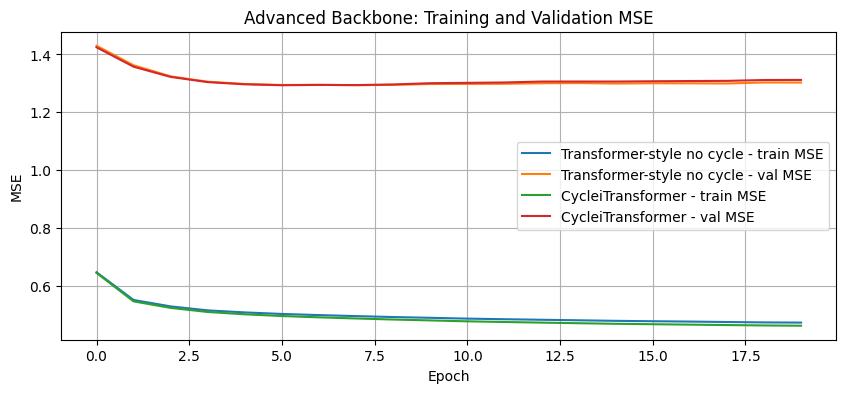

In [169]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(
    no_cycle_history["train_mse"],
    label="Transformer-style no cycle - train MSE"
)

plt.plot(
    no_cycle_history["val_mse"],
    label="Transformer-style no cycle - val MSE"
)

plt.plot(
    cycle_transformer_history["train_mse"],
    label="CycleiTransformer - train MSE"
)

plt.plot(
    cycle_transformer_history["val_mse"],
    label="CycleiTransformer - val MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Advanced Backbone: Training and Validation MSE")
plt.legend()
plt.grid(True)
plt.show()

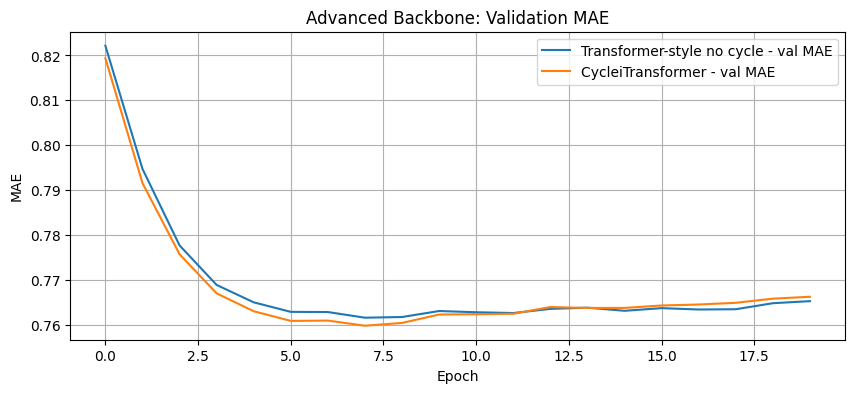

In [170]:
plt.figure(figsize=(10, 4))

plt.plot(
    no_cycle_history["val_mae"],
    label="Transformer-style no cycle - val MAE"
)

plt.plot(
    cycle_transformer_history["val_mae"],
    label="CycleiTransformer - val MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Advanced Backbone: Validation MAE")
plt.legend()
plt.grid(True)
plt.show()

Using a stronger Transformer-style backbone, the cycle module still improves performance, although the gain is smaller than in the Linear backbone experiment. CycleiTransformer reduces both MSE and MAE compared to the same inverted Transformer-style architecture without cycle modeling.

This suggests that explicit recurrent cycle modeling is not limited to simple Linear backbones. However, in our limited reimplementation setting, the simpler CycleNet-Linear model remains more competitive overall, indicating that increased architectural complexity does not automatically lead to better forecasting performance.

| Model                      | Test MSE | Test MAE |
| -------------------------- | -------: | -------: |
| Transformer-style no cycle | 0.480718 | 0.456953 |
| CycleiTransformer          | 0.475241 | 0.452285 |
